# PartitionTree Regressor — California Housing Dataset

This notebook demonstrates how to use `PartitionTreeRegressor` from the `partition_tree` library on the **California Housing** dataset from scikit-learn. We will train the model, make predictions, evaluate its performance, and compare it against a standard `DecisionTreeRegressor`.

## 1. Import Required Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from partition_tree.sklearn import PartitionTreeRegressor, PartitionForestRegressor

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## 2. Load and Explore the Dataset

We use the **California Housing** dataset (20 640 samples, 8 features). The target is the **median house value** (in units of $100 000).

In [5]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(f"Shape: {df.shape}")
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 3. Preprocess the Data

Split into train / test sets (80 / 20) and scale features with `StandardScaler`.

In [7]:
X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=24
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set : {X_train_scaled.shape}")
print(f"Test set     : {X_test_scaled.shape}")

Training set : (16512, 8)
Test set     : (4128, 8)


## 4. Initialize and Train the PartitionTree Regressor

Key hyperparameters:
- **`max_leaves`** — maximum number of leaves (controls model complexity).
- **`max_depth`** — maximum tree depth.
- **`min_samples_split`** — minimum number of samples required to split a node.

In [56]:
pt_regressor = PartitionTreeRegressor(
    max_leaves=None,
    max_depth=4000,
    min_samples_xy=1,
    min_samples_x=1,
    min_volume_fraction=0.05,
    min_gain=0.0,
    boundaries_expansion_factor=0.05,
    loss=None
)
pf_regressor= PartitionForestRegressor(
    n_estimators=20,
    max_leaves=None,
    max_depth=3000,
    min_samples_xy=0.0,
    min_samples_x=1.0,
    min_samples_y=1.0,
    min_volume_fraction=0.05,
    max_samples=1,
    max_features=1,
    loss=None,
    random_state=20,
    boundaries_expansion_factor=0.05,
)

pt_regressor.fit(X_train_scaled, y_train)
pf_regressor.fit(X_train_scaled, y_train)
print("PartitionTreeRegressor trained successfully.")

PartitionTreeRegressor trained successfully.


## 5. Make Predictions

Run inference on the test set and preview the first predictions alongside their true values.

In [58]:
y_pred_pt = pt_regressor.predict(X_test_scaled)
y_pred_pf = pf_regressor.predict(X_test_scaled)

# Also train a baseline DecisionTreeRegressor for comparison
dt_regressor = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_regressor.fit(X_train_scaled, y_train)
y_pred_dt = dt_regressor.predict(X_test_scaled)

# Random forest
from sklearn.ensemble import RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=100, max_depth=30, random_state=42)
rf_regressor.fit(X_train_scaled, y_train)
y_pred_rf = rf_regressor.predict(X_test_scaled)

comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "PartitionTree": y_pred_pt[:10].round(3),
    "DecisionTree": y_pred_dt[:10].round(3),
    "PartitionForest": y_pred_pf[:10].round(3),
    "RandomForest": y_pred_rf[:10].round(3),
})
comparison

,Actual,PartitionTree,DecisionTree,PartitionForest,RandomForest
0,2.358,2.651,2.892,2.688,3.224
1,0.857,1.627,2.009,1.285,1.323
2,2.740,2.807,3.217,2.979,3.098
3,2.438,2.131,1.534,1.999,1.998
4,1.518,1.797,1.626,1.563,1.549
5,2.597,2.140,1.961,2.119,2.192
6,2.638,2.183,2.109,2.563,2.518
7,1.580,1.470,2.182,2.163,1.997
8,0.935,1.095,1.015,0.989,1.014
9,2.046,1.954,1.891,1.778,1.792


## 6. Evaluate the Model

We compare `PartitionTreeRegressor` against scikit-learn's `DecisionTreeRegressor` using:
- **MAE** — Mean Absolute Error
- **RMSE** — Root Mean Squared Error
- **$R^2$** — coefficient of determination

In [60]:
def regression_metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {"Model": label, "MAE": round(mae, 4), "RMSE": round(rmse, 4), "R²": round(r2, 4)}

metrics = pd.DataFrame([
    regression_metrics(y_test, y_pred_pt, "PartitionTreeRegressor"),
    regression_metrics(y_test, y_pred_dt, "DecisionTreeRegressor"),
    regression_metrics(y_test, y_pred_pf, "PartitionForestRegressor"),
    regression_metrics(y_test, y_pred_rf, "RandomForestRegressor"),
])
metrics.set_index("Model")

,MAE,RMSE,R²
Model,,,
PartitionTreeRegressor,0.3943,0.5902,0.7371
DecisionTreeRegressor,0.4272,0.6354,0.6953
PartitionForestRegressor,0.3404,0.5078,0.8054
RandomForestRegressor,0.3277,0.5027,0.8093


In [26]:
def regression_metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {"Model": label, "MAE": round(mae, 4), "RMSE": round(rmse, 4), "R²": round(r2, 4)}

metrics = pd.DataFrame([
    regression_metrics(y_test, y_pred_pt, "PartitionTreeRegressor"),
    regression_metrics(y_test, y_pred_dt, "DecisionTreeRegressor"),
    regression_metrics(y_test, y_pred_pf, "PartitionForestRegressor"),
    regression_metrics(y_test, y_pred_rf, "RandomForestRegressor"),
])
metrics.set_index("Model")

,MAE,RMSE,R²
Model,,,
PartitionTreeRegressor,0.4022,0.5908,0.7366
DecisionTreeRegressor,0.4272,0.6354,0.6953
PartitionForestRegressor,0.3393,0.5059,0.8068
RandomForestRegressor,0.3277,0.5027,0.8093


## 7. Visualize the Results

### 7.1 Predicted vs Actual values
A perfect model would place all points on the diagonal dashed line.

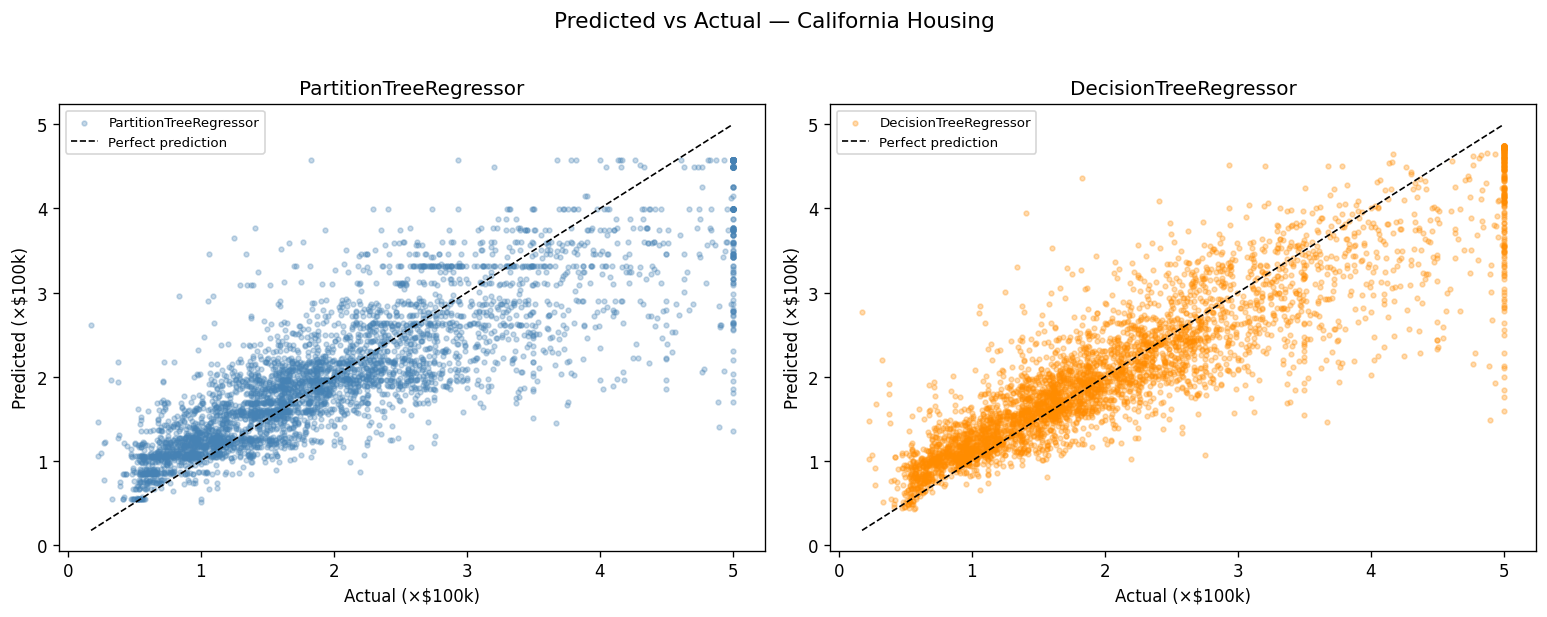

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, y_pred, title, color in zip(
    axes,
    [y_pred_pt, y_pred_pf],
    ["PartitionTreeRegressor", "DecisionTreeRegressor"],
    ["steelblue", "darkorange"],
):
    ax.scatter(y_test, y_pred, alpha=0.3, s=8, color=color, label=title)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "k--", linewidth=1, label="Perfect prediction")
    ax.set_xlabel("Actual (×$100k)")
    ax.set_ylabel("Predicted (×$100k)")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle("Predicted vs Actual — California Housing", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 7.2 Residuals Plot

Residuals should ideally be scattered randomly around zero without systematic patterns.

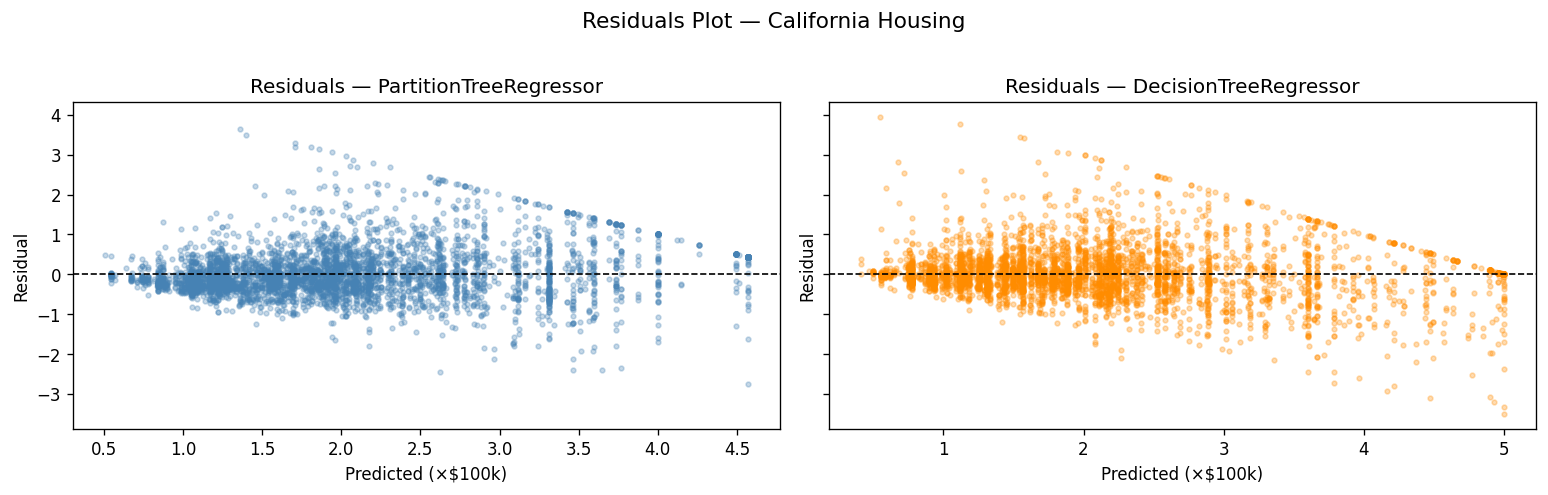

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, y_pred, title, color in zip(
    axes,
    [y_pred_pt, y_pred_dt],
    ["PartitionTreeRegressor", "DecisionTreeRegressor"],
    ["steelblue", "darkorange"],
):
    residuals = y_test.values - y_pred
    ax.scatter(y_pred, residuals, alpha=0.3, s=8, color=color)
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_xlabel("Predicted (×$100k)")
    ax.set_ylabel("Residual")
    ax.set_title(f"Residuals — {title}")

plt.suptitle("Residuals Plot — California Housing", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 7.3 Error Distribution

Distribution of absolute errors for both models.

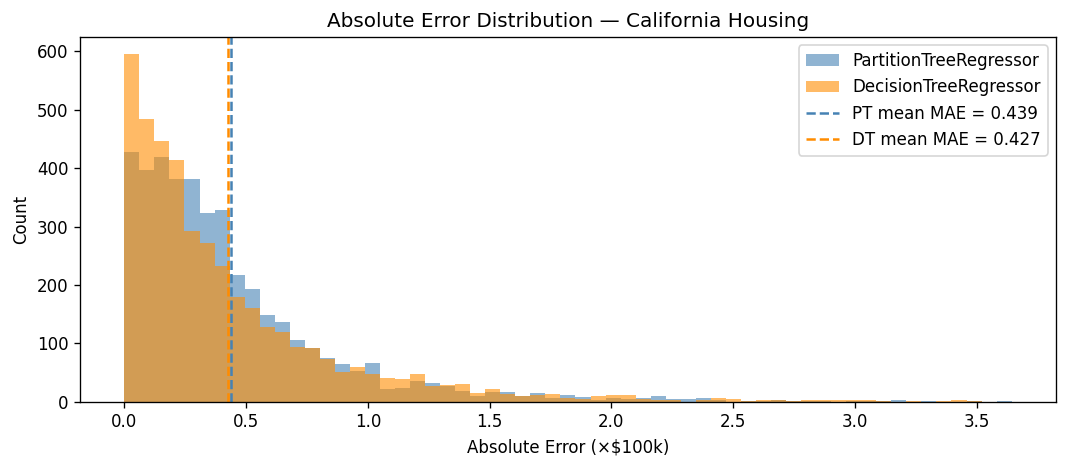

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))

abs_err_pt = np.abs(y_test.values - y_pred_pt)
abs_err_dt = np.abs(y_test.values - y_pred_dt)

bins = np.linspace(0, abs_err_pt.max(), 60)
ax.hist(abs_err_pt, bins=bins, alpha=0.6, color="steelblue", label="PartitionTreeRegressor")
ax.hist(abs_err_dt, bins=bins, alpha=0.6, color="darkorange", label="DecisionTreeRegressor")
ax.axvline(abs_err_pt.mean(), color="steelblue", linestyle="--", linewidth=1.5,
           label=f"PT mean MAE = {abs_err_pt.mean():.3f}")
ax.axvline(abs_err_dt.mean(), color="darkorange", linestyle="--", linewidth=1.5,
           label=f"DT mean MAE = {abs_err_dt.mean():.3f}")

ax.set_xlabel("Absolute Error (×$100k)")
ax.set_ylabel("Count")
ax.set_title("Absolute Error Distribution — California Housing")
ax.legend()
plt.tight_layout()
plt.show()